# Visualizing wavelet basis selection in `fcwt2`

This notebook highlights the named discrete wavelet bases added for wavelet packet and stationary transforms.

It shows:

- how Haar, Daubechies, and Symlet bases change detail coefficients
- how packet and stationary transforms reconstruct with non-Haar filters
- how the basis selector scores coarse-detail coefficient distribution shape

## Setup

If you are running this before the next package release, install the local checkout with `maturin develop` from the repository root. If the release is already available, installing `fcwt2` from PyPI is enough.

In [1]:
# Released package path:
# %pip install -q fcwt2 numpy matplotlib

# Local checkout path, run from the repository root or adjust the manifest path:
# %pip install -q maturin numpy matplotlib
# !maturin develop --manifest-path ../Cargo.toml

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import fcwt2

plt.rcParams.update(
    {
        "figure.figsize": (12, 4),
        "axes.grid": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

wavelet_names = ["haar", "db2", "db4", "db8", "sym4", "sym8"]
levels = 4

## A signal with structure at several scales

The signal combines a slow component, a localized oscillatory burst, a sharp impulse, and a little noise. Different bases spread those details differently across their coefficient distributions.

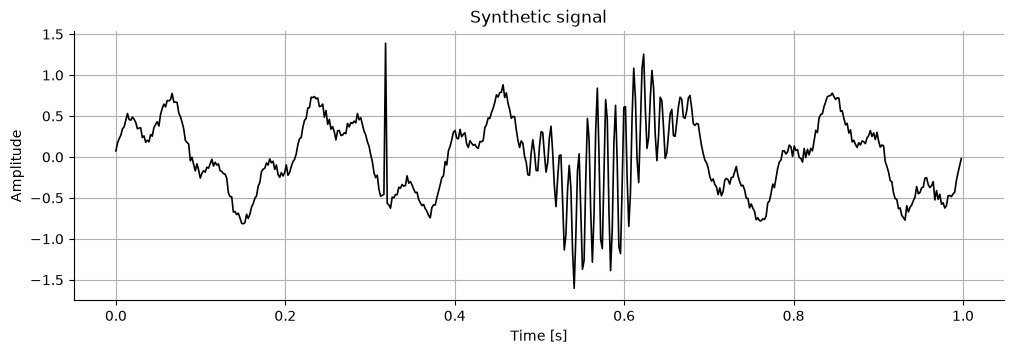

In [3]:
rng = np.random.default_rng(7)
sample_rate = 512
n = 512
t = np.arange(n) / sample_rate

slow = 0.55 * np.sin(2 * np.pi * 5.0 * t)
mid = 0.25 * np.sin(2 * np.pi * 18.0 * t + 0.3)
burst_window = np.exp(-0.5 * ((t - 0.58) / 0.045) ** 2)
burst = 1.05 * burst_window * np.sin(2 * np.pi * 92.0 * t)
impulse = np.zeros_like(t)
impulse[int(0.32 * sample_rate)] = 2.0
noise = 0.045 * rng.standard_normal(n)

signal = (slow + mid + burst + impulse + noise).astype(np.float32)

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(t, signal, color="black", lw=1.2)
ax.set(title="Synthetic signal", xlabel="Time [s]", ylabel="Amplitude")
plt.show()

In [4]:
def max_abs_error(original, reconstructed):
    original = np.asarray(original, dtype=float)
    reconstructed = np.asarray(reconstructed, dtype=float)
    return float(np.max(np.abs(original - reconstructed)))


def packet_leaf_matrix(tree):
    leaves = tree.leaves()
    labels = ["".join(leaf.path) for leaf in leaves]
    matrix = np.asarray([leaf.coefficients for leaf in leaves], dtype=float)
    return labels, matrix


def plot_histograms(details_by_wavelet, title):
    columns = 3
    rows = int(np.ceil(len(details_by_wavelet) / columns))
    fig, axes = plt.subplots(
        rows, columns, figsize=(12, 2.6 * rows), constrained_layout=True
    )
    axes = np.asarray(axes).reshape(-1)
    for ax, (name, values) in zip(axes, details_by_wavelet.items()):
        ax.hist(values, bins=28, color="tab:blue", alpha=0.78)
        ax.axvline(0.0, color="black", lw=1.0)
        ax.set(title=name, xlabel="Coefficient", ylabel="Count")
    for ax in axes[len(details_by_wavelet) :]:
        ax.axis("off")
    fig.suptitle(title, y=1.02, fontsize=14)
    plt.show()

## Wavelet packet coefficients across bases

A packet tree splits every branch. The heatmaps below show absolute leaf coefficients for the same signal under different bases. Compact high-energy patches mean a basis is concentrating structure into fewer coefficients.

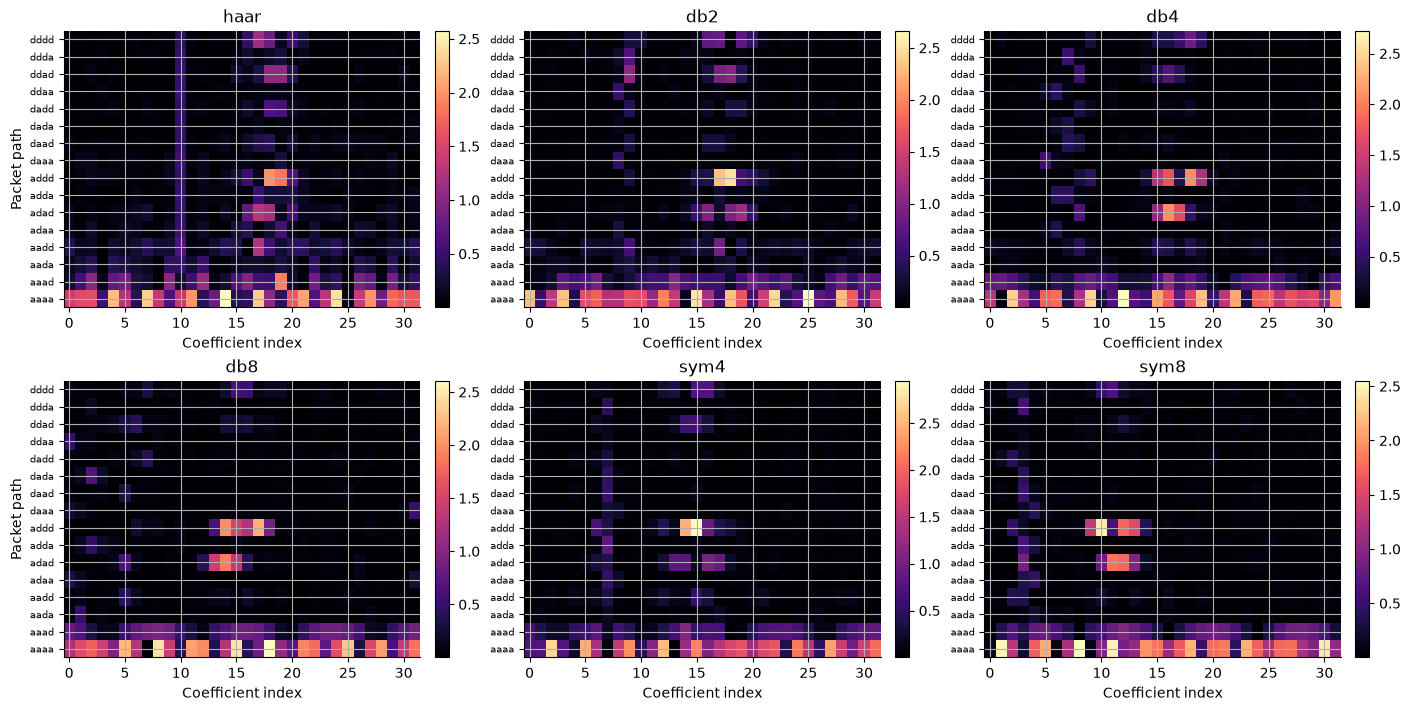

 haar packet max reconstruction error: 3.576e-07
  db2 packet max reconstruction error: 2.384e-07
  db4 packet max reconstruction error: 3.576e-07
  db8 packet max reconstruction error: 4.172e-07
 sym4 packet max reconstruction error: 4.768e-07
 sym8 packet max reconstruction error: 5.364e-07


In [5]:
packet_trees = {}
packet_reconstruction_errors = {}

fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
axes = axes.reshape(-1)

for ax, name in zip(axes, wavelet_names):
    transform = fcwt2.WaveletPacketTransform.with_wavelet(levels, name)
    tree = transform.decompose(signal.tolist())
    labels, matrix = packet_leaf_matrix(tree)
    packet_trees[name] = tree
    packet_reconstruction_errors[name] = max_abs_error(signal, tree.reconstruct())

    image = ax.imshow(np.abs(matrix), aspect="auto", origin="lower", cmap="magma")
    ax.set(title=name, xlabel="Coefficient index")
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=7)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

axes[0].set_ylabel("Packet path")
axes[3].set_ylabel("Packet path")
plt.show()

for name, error in packet_reconstruction_errors.items():
    print(f"{name:>5} packet max reconstruction error: {error:.3e}")

## Stationary detail bands across bases

The stationary transform keeps every level aligned to the original sample grid. That makes it easy to compare where the bases respond to the impulse and the burst.

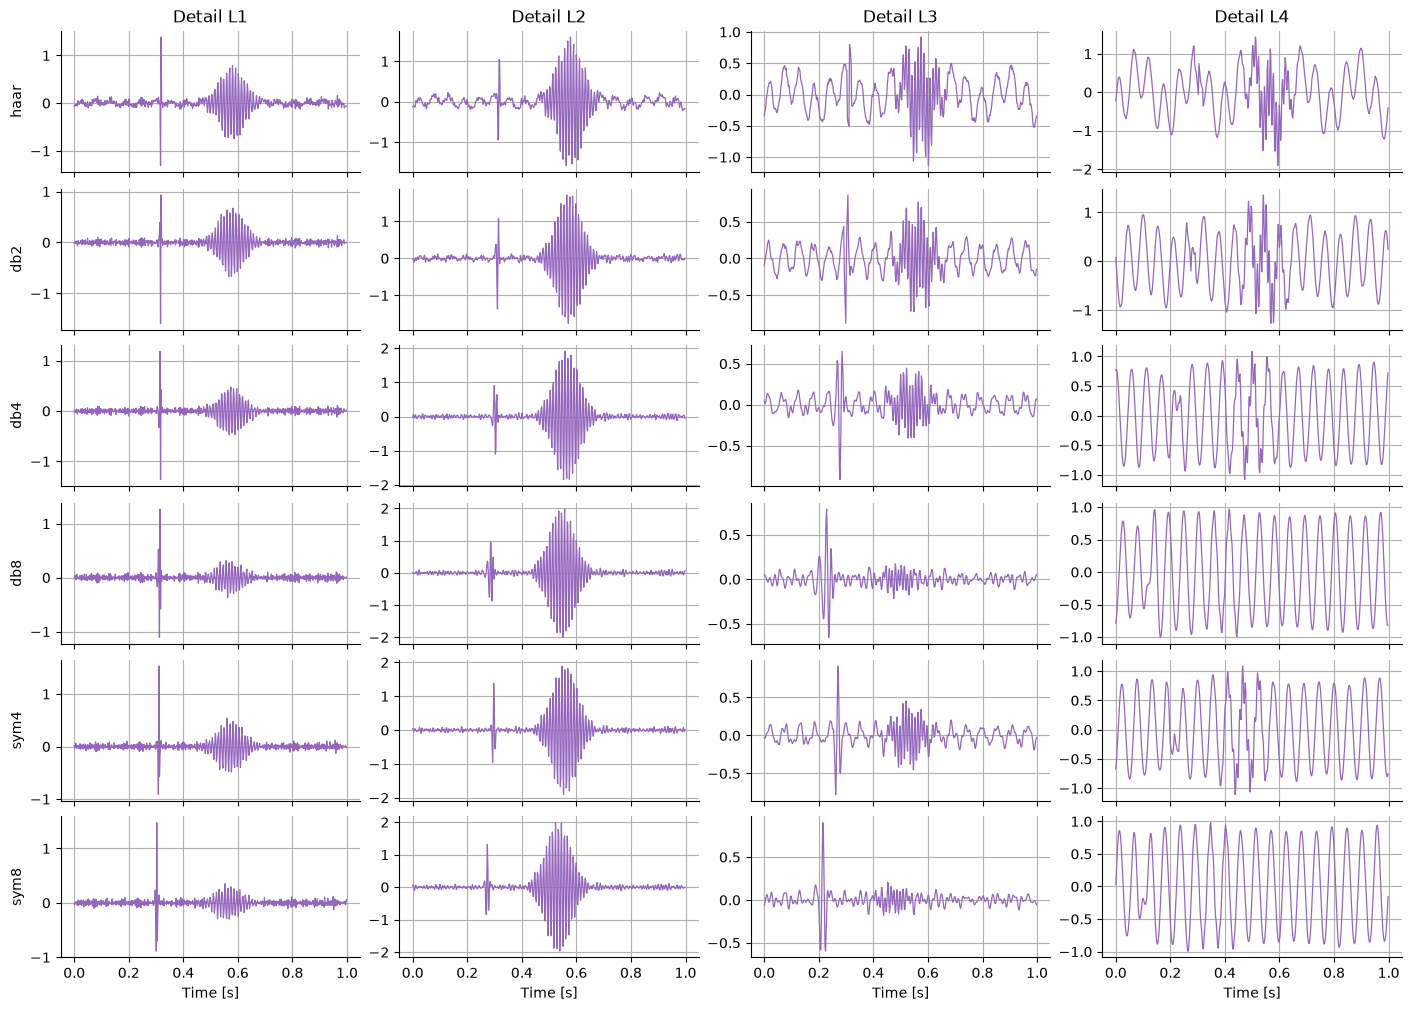

 haar SWT max reconstruction error: 2.384e-07
  db2 SWT max reconstruction error: 2.384e-07
  db4 SWT max reconstruction error: 2.384e-07
  db8 SWT max reconstruction error: 2.384e-07
 sym4 SWT max reconstruction error: 3.576e-07
 sym8 SWT max reconstruction error: 3.576e-07


In [6]:
swt_coefficients = {}
swt_reconstruction_errors = {}

fig, axes = plt.subplots(
    len(wavelet_names), levels, figsize=(14, 10), sharex=True, constrained_layout=True
)

for row, name in enumerate(wavelet_names):
    transform = fcwt2.StationaryWaveletTransform.with_wavelet(levels, name)
    coeffs = transform.decompose(signal.tolist())
    swt_coefficients[name] = coeffs
    swt_reconstruction_errors[name] = max_abs_error(
        signal, transform.reconstruct(coeffs)
    )

    for col, level in enumerate(coeffs.levels()):
        axes[row, col].plot(t, level.detail, color="tab:purple", lw=0.9)
        if row == 0:
            axes[row, col].set_title(f"Detail L{col + 1}")
        if col == 0:
            axes[row, col].set_ylabel(name)

for ax in axes[-1, :]:
    ax.set_xlabel("Time [s]")
plt.show()

for name, error in swt_reconstruction_errors.items():
    print(f"{name:>5} SWT max reconstruction error: {error:.3e}")

## Coarsest-detail distribution shape

The selector scores the retained coarsest detail band. Lower robust width and higher central concentration or sharpness increase the score.

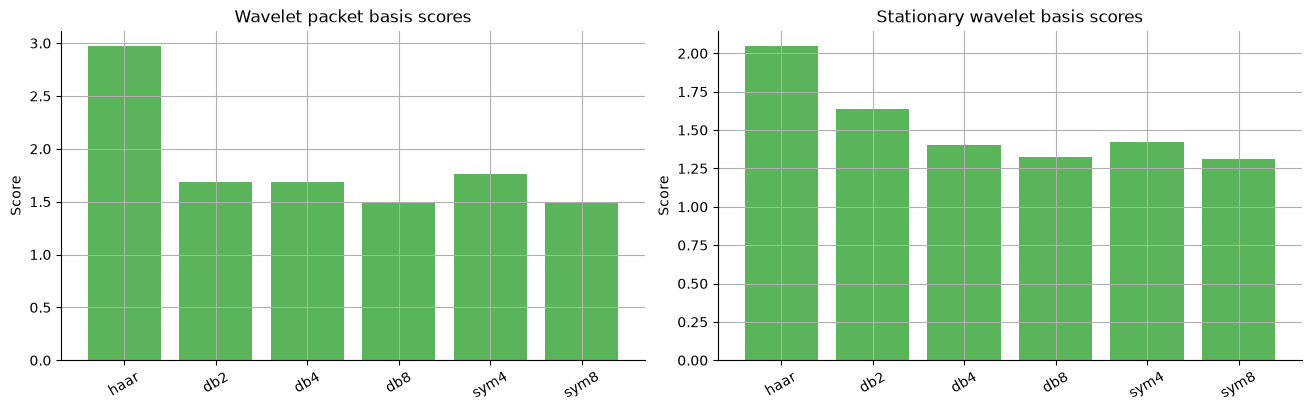

Selected packet basis: haar
Selected SWT basis: haar


In [7]:
packet_scores = [
    fcwt2.score_basis(signal.tolist(), levels, name, "wavelet_packet")
    for name in wavelet_names
]
swt_scores = [
    fcwt2.score_basis(signal.tolist(), levels, name, "stationary")
    for name in wavelet_names
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
for ax, title, scores in [
    (axes[0], "Wavelet packet", packet_scores),
    (axes[1], "Stationary wavelet", swt_scores),
]:
    names = [score.wavelet for score in scores]
    values = [score.score for score in scores]
    ax.bar(names, values, color="tab:green", alpha=0.78)
    ax.set(title=f"{title} basis scores", ylabel="Score")
    ax.tick_params(axis="x", rotation=30)
plt.show()

selected_packet = fcwt2.select_basis(
    signal.tolist(), levels, wavelet_names, "wavelet_packet"
)
selected_swt = fcwt2.select_basis(signal.tolist(), levels, wavelet_names, "stationary")

print("Selected packet basis:", selected_packet.selected)
print("Selected SWT basis:", selected_swt.selected)

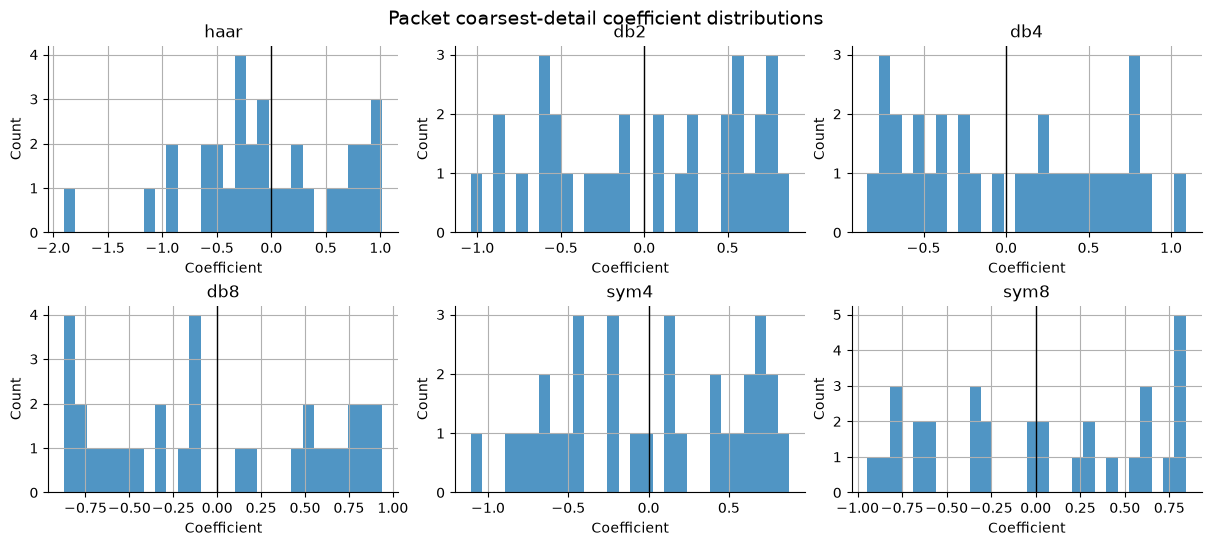

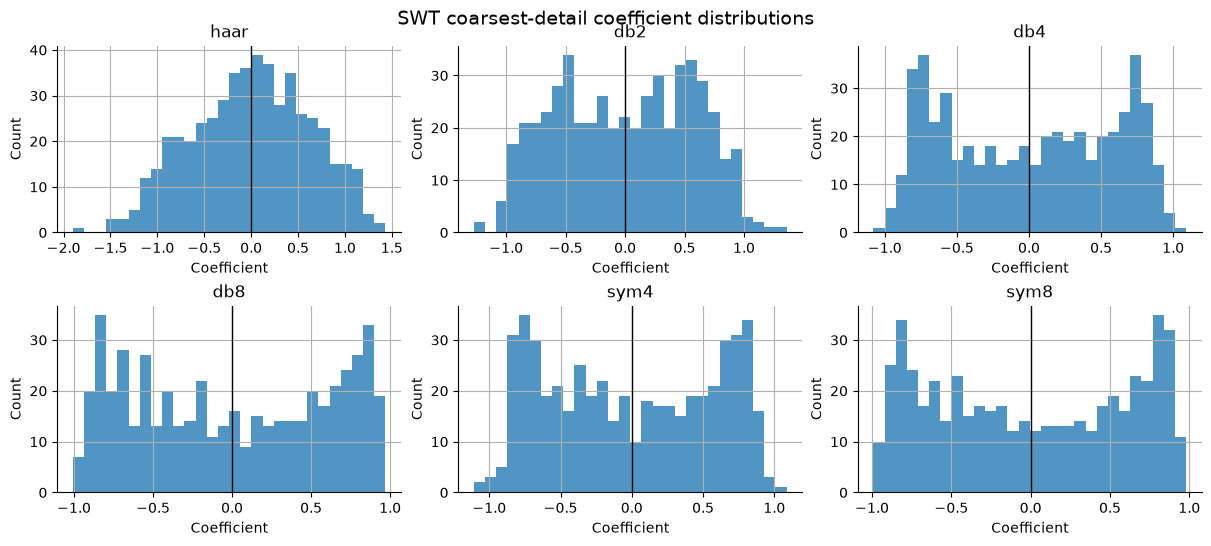

In [8]:
packet_detail_by_wavelet = {}
for name, tree in packet_trees.items():
    coarsest_detail_path = "a" * (levels - 1) + "d"
    for leaf in tree.leaves():
        if "".join(leaf.path) == coarsest_detail_path:
            packet_detail_by_wavelet[name] = np.asarray(leaf.coefficients, dtype=float)
            break

swt_detail_by_wavelet = {
    name: np.asarray(coeffs.levels()[-1].detail, dtype=float)
    for name, coeffs in swt_coefficients.items()
}

plot_histograms(
    packet_detail_by_wavelet, "Packet coarsest-detail coefficient distributions"
)
plot_histograms(swt_detail_by_wavelet, "SWT coarsest-detail coefficient distributions")

## Inspecting selector diagnostics

Each score object exposes the selected basis name, score, coefficient count, robust width metrics, central concentration, and sharpness.

In [9]:
for score in selected_packet.candidate_scores():
    print(
        f"{score.wavelet:>5} | score={score.score:8.3f} | "
        f"MAD={score.median_abs_deviation:7.4f} | "
        f"IQR={score.interquartile_range:7.4f} | "
        f"central={score.central_concentration:5.2f} | "
        f"sharpness={score.sharpness:7.2f} | "
        f"pdf_peak={score.pdf_peak:5.2f} | "
        f"pdf_entropy={score.pdf_entropy:5.2f} | "
        f"n={score.coefficient_count}"
    )

 haar | score=   2.969 | MAD= 0.5209 | IQR= 0.6052 | central= 0.28 | sharpness=   3.18 | pdf_peak= 0.34 | pdf_entropy= 0.87 | n=32
  db2 | score=   1.690 | MAD= 0.5656 | IQR= 0.4264 | central= 0.28 | sharpness=   1.64 | pdf_peak= 0.28 | pdf_entropy= 0.93 | n=32
  db4 | score=   1.686 | MAD= 0.5562 | IQR= 0.4350 | central= 0.28 | sharpness=   1.68 | pdf_peak= 0.22 | pdf_entropy= 0.95 | n=32
  db8 | score=   1.484 | MAD= 0.6486 | IQR= 0.4801 | central= 0.28 | sharpness=   1.52 | pdf_peak= 0.22 | pdf_entropy= 0.97 | n=32
 sym4 | score=   1.759 | MAD= 0.5858 | IQR= 0.4452 | central= 0.28 | sharpness=   1.71 | pdf_peak= 0.25 | pdf_entropy= 0.92 | n=32
 sym8 | score=   1.498 | MAD= 0.6192 | IQR= 0.4592 | central= 0.28 | sharpness=   1.55 | pdf_peak= 0.19 | pdf_entropy= 0.97 | n=32


## Reconstruct with the selected bases

The selected basis can be fed back into the transform constructor. Reconstruction should remain close to the original signal because the transform stores and uses the corresponding synthesis filters.

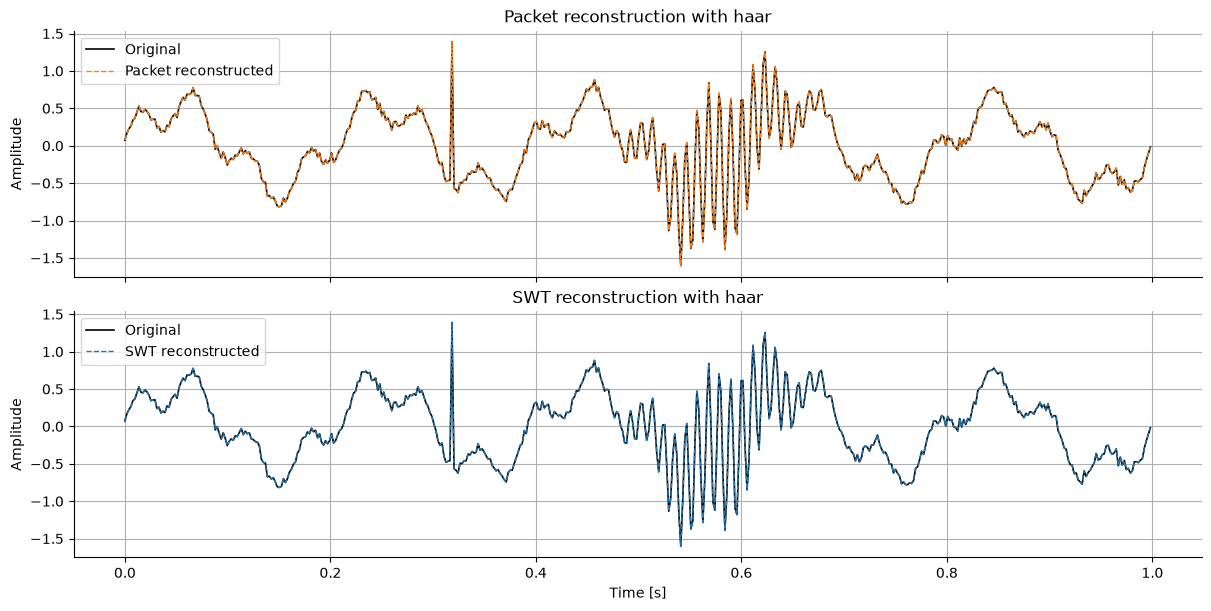

Packet selected-basis max error: 3.576e-07
SWT selected-basis max error:    2.384e-07


In [10]:
packet_transform = fcwt2.WaveletPacketTransform.with_wavelet(
    levels, selected_packet.selected
)
packet_tree = packet_transform.decompose(signal.tolist())
packet_reconstructed = np.asarray(packet_tree.reconstruct(), dtype=float)

swt_transform = fcwt2.StationaryWaveletTransform.with_wavelet(
    levels, selected_swt.selected
)
swt_coeffs = swt_transform.decompose(signal.tolist())
swt_reconstructed = np.asarray(swt_transform.reconstruct(swt_coeffs), dtype=float)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, constrained_layout=True)
axes[0].plot(t, signal, color="black", lw=1.2, label="Original")
axes[0].plot(
    t,
    packet_reconstructed,
    color="tab:orange",
    lw=1.0,
    ls="--",
    label="Packet reconstructed",
)
axes[0].set(
    title=f"Packet reconstruction with {selected_packet.selected}", ylabel="Amplitude"
)
axes[0].legend(loc="upper left")

axes[1].plot(t, signal, color="black", lw=1.2, label="Original")
axes[1].plot(
    t, swt_reconstructed, color="tab:blue", lw=1.0, ls="--", label="SWT reconstructed"
)
axes[1].set(
    title=f"SWT reconstruction with {selected_swt.selected}",
    xlabel="Time [s]",
    ylabel="Amplitude",
)
axes[1].legend(loc="upper left")
plt.show()

print(
    f"Packet selected-basis max error: {max_abs_error(signal, packet_reconstructed):.3e}"
)
print(
    f"SWT selected-basis max error:    {max_abs_error(signal, swt_reconstructed):.3e}"
)

## Takeaways

- `new(levels)` remains the Haar default.
- `with_wavelet(levels, name)` lets packet and stationary transforms use named Daubechies and Symlet bases.
- `score_basis` and `select_basis` are small diagnostics helpers, not denoisers.
- The score is most useful as one signal-specific clue alongside reconstruction checks and downstream validation.